# COVID Excess Deaths


## Data import

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import calendar
from scipy import stats
from pathlib import Path

data_dir = Path.cwd() / "data"

In [48]:
DATA = {
    "by_year":       "./data/COVIDBACKGROUNDS - DeathsByYear.csv",
    "by_month":      "./data/COVIDBACKGROUNDS - DeathsByYearAndMonth.csv",
    "by_sex_age":    "./data/COVIDBACKGROUNDS - DeathsByYearSexAge.csv",
    "income_totals": "./data/COVIDBACKGROUNDS - IncomeDeaths.csv",
    "income_sex_age":"./data/COVIDBACKGROUNDS - IncomeDeathsByYearSexAgeIncome.csv",
    "income_monthly":"./data/COVIDBACKGROUNDS - IncomeDeathsYearlyMonth.csv",
    "region_totals": "./data/COVIDBACKGROUNDS - RegionDeathsByYearAndMonth.csv",
    "region_sex_age":"./data/COVIDBACKGROUNDS - RegionDeathsByYearSexAndAge.csv",
    "vaccinations":  "./data/country_vaccinations.csv",
    "complete":      "./data/covid_19_clean_complete.csv",
    "stringency":    "./data/OxCGRT_compact_national_v1.csv",
}

by_year        = pd.read_csv(DATA["by_year"])
by_month       = pd.read_csv(DATA["by_month"])
by_sex_age     = pd.read_csv(DATA["by_sex_age"])
income_totals  = pd.read_csv(DATA["income_totals"])
income_sex_age = pd.read_csv(DATA["income_sex_age"])
income_monthly = pd.read_csv(DATA["income_monthly"])
region_totals  = pd.read_csv(DATA["region_totals"])
region_sex_age = pd.read_csv(DATA["region_sex_age"])
complete       = pd.read_csv(DATA["complete"])
stringency     = pd.read_csv(DATA["stringency"])
vaccinations   = pd.read_csv(DATA["vaccinations"], engine="python", on_bad_lines="skip")


for df in [by_year, by_month, by_sex_age, income_totals,
           income_sex_age, income_monthly, region_totals, region_sex_age]:
    df.columns = [c.replace("*", "").strip() for c in df.columns]

EXCESS = "excess.mean"
print(f"All files loaded.")
print(f"  vaccinations : {len(vaccinations):,} rows | country dtype: {vaccinations['country'].dtype}")
print(f"  stringency   : {len(stringency):,} rows")

All files loaded.
  vaccinations : 86,512 rows | country dtype: str
  stringency   : 202,760 rows


## Data Cleanup

In [49]:
# cleanup - strips * from columns (if any)
by_year.columns        = [c.replace("*", "").strip() for c in by_year.columns]
by_month.columns       = [c.replace("*", "").strip() for c in by_month.columns]
by_sex_age.columns     = [c.replace("*", "").strip() for c in by_sex_age.columns]
income_totals.columns  = [c.replace("*", "").strip() for c in income_totals.columns]
income_sex_age.columns = [c.replace("*", "").strip() for c in income_sex_age.columns]
income_monthly.columns = [c.replace("*", "").strip() for c in income_monthly.columns]
region_totals.columns  = [c.replace("*", "").strip() for c in region_totals.columns]
region_sex_age.columns = [c.replace("*", "").strip() for c in region_sex_age.columns]

## Function Definitions

In [50]:
# defining functions
def sep(title):
    print(f"\n{'='*62}\n  {title}\n{'='*62}")

def fmt_millions(x, _):
    return f"{x/1e6:.1f}M" if abs(x) >= 1e6 else f"{x/1e3:.0f}K"

def save_fig(name):
    target_dir = Path("plots")
    target_dir.mkdir(parents=True, exist_ok=True)
    file_path = target_dir / f"{name}.png"
    
    plt.tight_layout()
    plt.savefig(file_path, dpi=150, bbox_inches="tight",
                facecolor=plt.rcParams["figure.facecolor"])
    plt.show()
    print(f"  [saved {file_path.absolute()}]")

# GLOBAL EXCESS


  1. GLOBAL EXCESS DEATHS BY YEAR
     year  excess.mean  excess.low  excess.high
     2020      4437866     3884591      5031188
     2021     10425021     9108243     12071762
2020-2021     14862887    13278860     16625075

  Total: 29,725,774


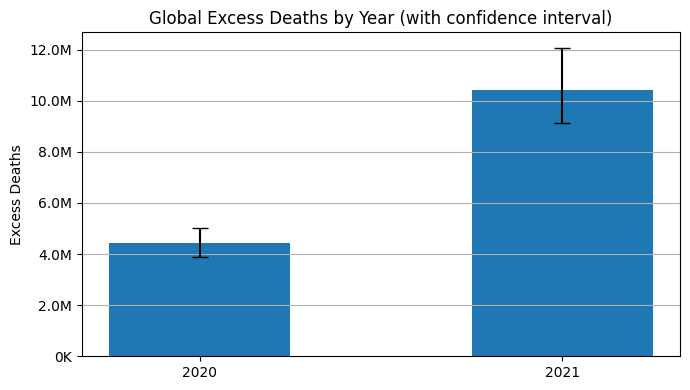

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot1_global_excess_deaths.png]


In [51]:
sep("1. GLOBAL EXCESS DEATHS BY YEAR")

global_row = region_totals[region_totals["location"] == "Global"].copy()
global_yr  = global_row[global_row["year"].astype(str).str.match(r"^\d{4}$")]
print(global_row[["year", EXCESS, "excess.low", "excess.high"]].to_string(index=False))
print(f"\n  Total: {global_row[EXCESS].sum():,.0f}")

fig, ax = plt.subplots(figsize=(7, 4))
years  = global_yr["year"].astype(str).tolist()
values = global_yr[EXCESS].tolist()
lows   = global_yr["excess.low"].tolist()
highs  = global_yr["excess.high"].tolist()
bars   = ax.bar(years, values, width=0.5)
for bar, lo, hi in zip(bars, lows, highs):
    x = bar.get_x() + bar.get_width() / 2
    ax.errorbar(x, bar.get_height(),
                yerr=[[bar.get_height() - lo], [hi - bar.get_height()]],
                fmt="none", color="black", capsize=6, linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
ax.set_title("Global Excess Deaths by Year (with confidence interval)")
ax.set_ylabel("Excess Deaths")
ax.grid(axis="y")
save_fig("plot1_global_excess_deaths")

# TOP 10 GLOBAL EXCESS



  2. TOP GLOBAL EXCESS DEATHS


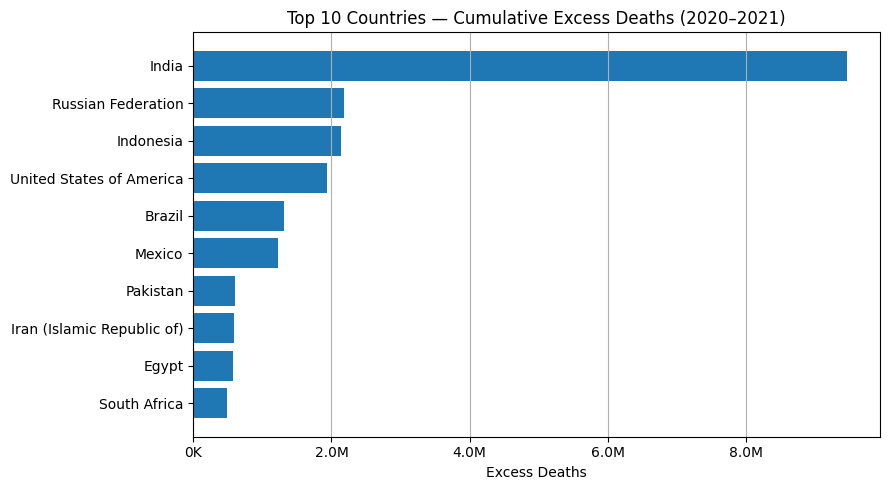

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot2_top10_countries.png]


In [52]:
sep("2. TOP GLOBAL EXCESS DEATHS")
country_totals = by_year.groupby(["Country", "iso3"])[EXCESS].sum().reset_index().sort_values(EXCESS, ascending=False)
top10 = country_totals.head(10).sort_values(EXCESS)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10["Country"], top10[EXCESS])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
ax.set_title("Top 10 Countries — Cumulative Excess Deaths (2020–2021)")
ax.set_xlabel("Excess Deaths")
ax.grid(axis="x")
save_fig("plot2_top10_countries")


In [53]:
## TODO:
## Negative Excess Deaths by Country (xyl)
## Excess Deaths by Income (feni)
## Global Monthly Excess Deaths (zoe)
## Excess Deaths by Age (urielle)
## Excess Deaths by Sex (tas kung sino avail)

# TOP 10 NEGATIVE EXCESS DEATHS


  3. TOP NEGATIVE EXCESS DEATHS BY COUNTRY
Top 10 Countries with Most Negative Excess Deaths (2020-2021):
                    Country iso3  excess.mean
                    Uruguay  URY        -2272
                  Australia  AUS        -3167
United Republic of Tanzania  TZA        -5321
                New Zealand  NZL        -5541
                Philippines  PHL       -11683
                   Malaysia  MYS       -14019
                      Japan  JPN       -21921
                  Sri Lanka  LKA       -26476
                   Viet Nam  VNM       -96570
                      China  CHN      -127578


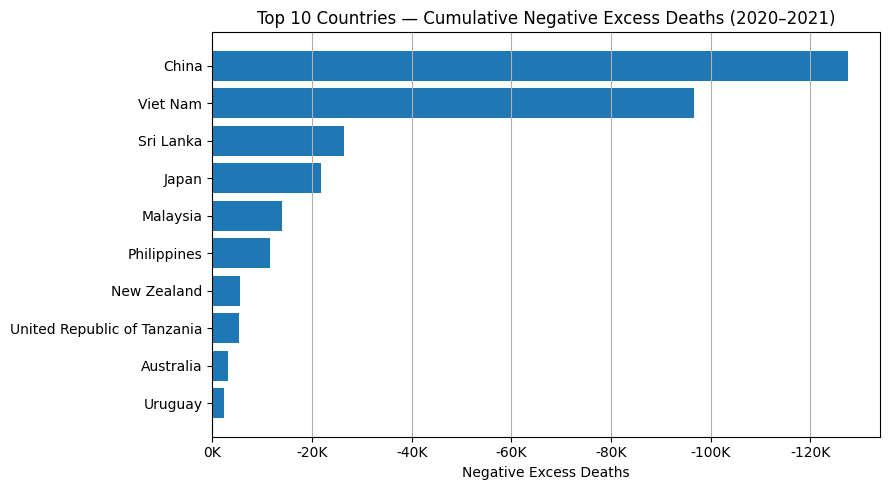

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot3_negative_excess_deaths.png]


In [54]:
sep("3. TOP NEGATIVE EXCESS DEATHS BY COUNTRY")

negative_excess = by_year[by_year[EXCESS] < 0].copy()
country_negative_excess = negative_excess.groupby(["Country", "iso3"])[EXCESS].sum().reset_index().sort_values(EXCESS)
top10_negative = country_negative_excess.head(10).sort_values(EXCESS, ascending=False)

print("Top 10 Countries with Most Negative Excess Deaths (2020-2021):")
print(top10_negative.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_negative["Country"], top10_negative[EXCESS])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
ax.set_title("Top 10 Countries — Cumulative Negative Excess Deaths (2020–2021)")
ax.set_xlabel("Negative Excess Deaths")
ax.grid(axis="x")
ax.invert_xaxis()
save_fig("plot3_negative_excess_deaths")

# EXCESS BY INCOME GROUP



  4. EXCESS DEATHS BY INCOME GROUP


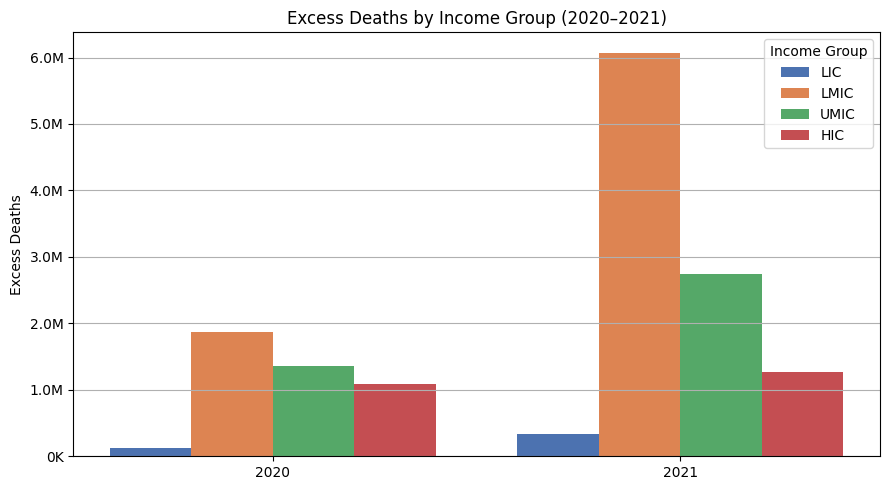

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot4_excess_by_income.png]


In [55]:
sep("4. EXCESS DEATHS BY INCOME GROUP")
# Filter out combined year rows
income_yr = income_totals[income_totals["year"].astype(str).str.match(r"^\d{4}$")]

fig, ax = plt.subplots(figsize=(9, 5))

income_groups = income_yr["income"].unique()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, inc in enumerate(income_groups):
    subset = income_yr[income_yr["income"] == inc].sort_values("year")
    years = subset["year"].astype(str).tolist()
    values = subset[EXCESS].tolist()
    x = [j + i * 0.2 for j in range(len(years))]
    ax.bar(x, values, width=0.2, label=inc, color=colors[i % len(colors)])

ax.set_xticks([j + 0.3 for j in range(len(years))])
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
ax.set_title("Excess Deaths by Income Group (2020–2021)")
ax.set_ylabel("Excess Deaths")
ax.legend(title="Income Group")
ax.grid(axis="y")
save_fig("plot4_excess_by_income")


#GLOBAL MONTHLY EXCESS DEATHS


  5. GLOBAL MONTHLY EXCESS DEATHS
 year  month  excess.mean
 2020      1       269873
 2020      2      -107603
 2020      3      -162568
 2020      4      -221182
 2020      5        25243
 2020      6       353765
 2020      7       582857
 2020      8       629388
 2020      9       611566
 2020     10       677497
 2020     11       824088
 2020     12       954979
 2021      1      1013374
 2021      2       394187
 2021      3       495020
 2021      4       824978
 2021      5      1737019
 2021      6      1540900
 2021      7      1064909
 2021      8       873819
 2021      9       616986
 2021     10       649105
 2021     11       611335
 2021     12       603387


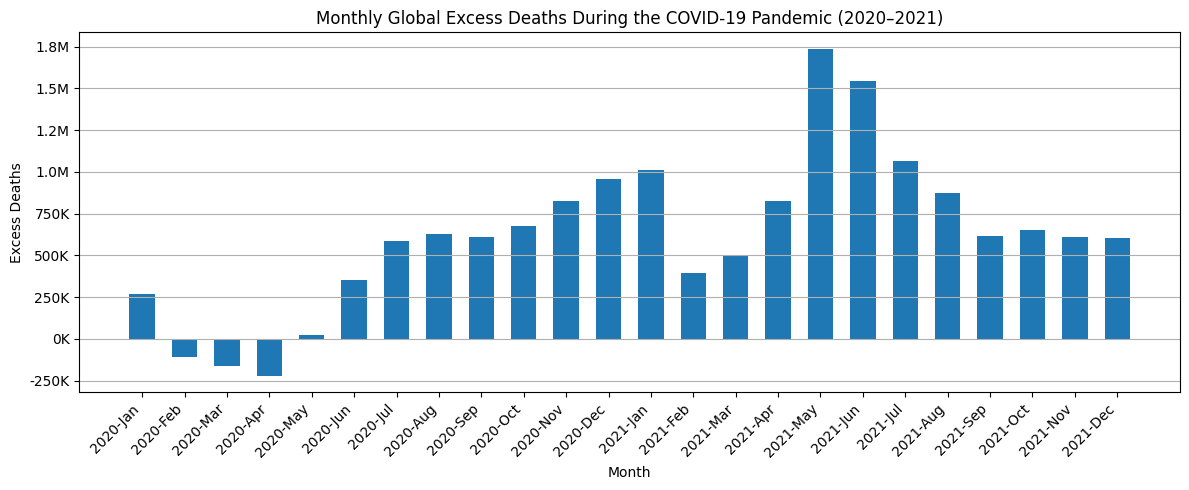

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot5_global_monthly_excess.png]


In [56]:
sep("5. GLOBAL MONTHLY EXCESS DEATHS")

import calendar

# Since there is no 'Global' row in the dataset,
# compute global monthly excess deaths by summing all countries
global_monthly = (
    by_month[by_month["year"].isin([2020, 2021])]
    .groupby(["year", "month"])[EXCESS]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

global_monthly["label"] = (
    global_monthly["year"].astype(str)
    + "-"
    + global_monthly["month"].apply(lambda m: calendar.month_abbr[int(m)])
)

print(global_monthly[["year", "month", EXCESS]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(global_monthly["label"], global_monthly[EXCESS], width=0.6)
ax.set_title("Monthly Global Excess Deaths During the COVID-19 Pandemic (2020–2021)")
ax.set_xlabel("Month")
ax.set_ylabel("Excess Deaths")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y")
save_fig("plot5_global_monthly_excess")

# EXCESS BY AGE


  6. GLOBAL EXCESS DEATHS BY AGE GROUP


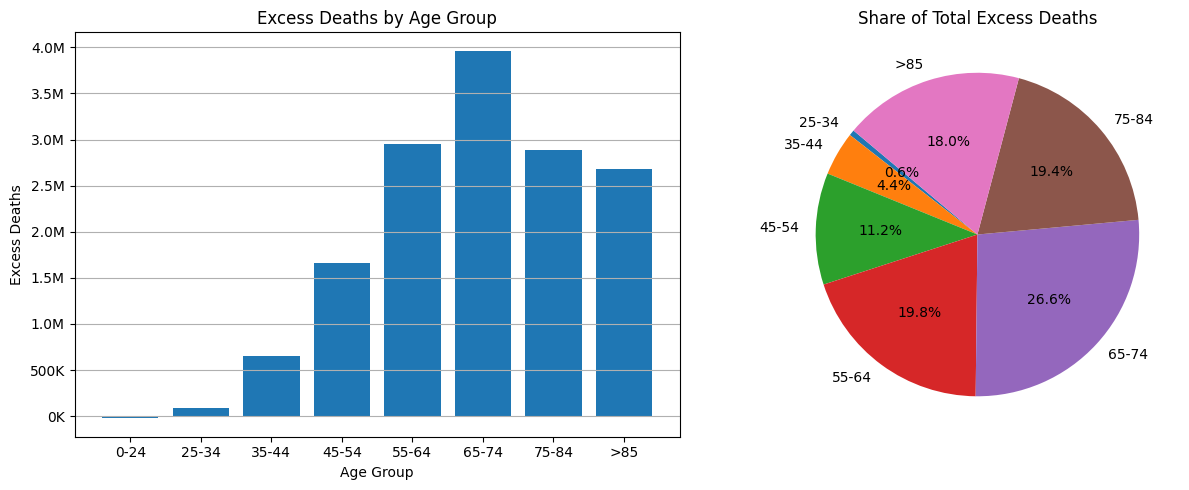

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot6_age_distribution.png]


In [57]:
#Excess Deaths by Age (urielle)

sep("6. GLOBAL EXCESS DEATHS BY AGE GROUP")
age_global = region_sex_age[(region_sex_age["location"] == "Global") & (region_sex_age["type"] == "predicted")]

age_summary = (age_global.groupby("age_group")[EXCESS].sum().reset_index().sort_values(EXCESS, ascending = False))
total_age = age_summary[EXCESS].sum()

age_summary["pct"] = (age_summary[EXCESS] / total_age * 100).round(1)

age_order = ["0-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75-84", ">85"]
age_plot  = age_summary.set_index("age_group").reindex(age_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(age_plot["age_group"], age_plot[EXCESS])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
axes[0].set_title("Excess Deaths by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Excess Deaths")
axes[0].grid(axis="y")

pos = age_plot[age_plot[EXCESS] > 0]
axes[1].pie(pos[EXCESS], labels=pos["age_group"], autopct="%1.1f%%", startangle=140)
axes[1].set_title("Share of Total Excess Deaths")
save_fig("plot6_age_distribution")



# EXCESS BY SEX


  7. GLOBAL EXCESS DEATHS BY SEX


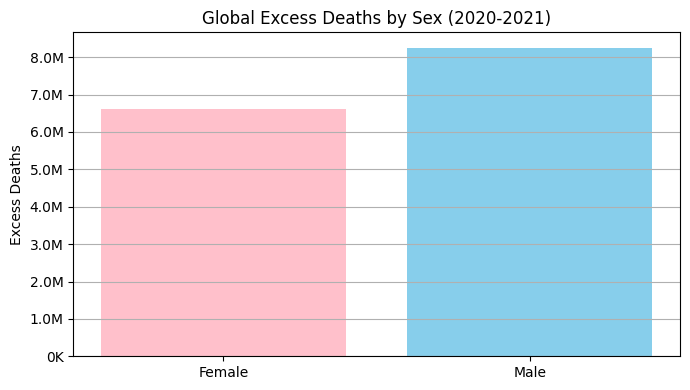

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot7_excess_deaths_by_sex.png]


In [58]:
sep("7. GLOBAL EXCESS DEATHS BY SEX")

filtered_sex_age = by_sex_age[by_sex_age['year'].isin([2020,2021])]
sex_excess_data = filtered_sex_age.groupby('sex')[EXCESS].sum().reset_index()

sex_excess_plot_data = sex_excess_data[sex_excess_data['sex'].isin(['Female', 'Male'])].sort_values(EXCESS)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sex_excess_plot_data["sex"], sex_excess_plot_data[EXCESS], color=['pink', 'skyblue'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
ax.set_title("Global Excess Deaths by Sex (2020-2021)")
ax.set_ylabel("Excess Deaths")
ax.grid(axis="y")
save_fig("plot7_excess_deaths_by_sex")

In [59]:
# Vaccination rate vs excess deaths (scatter + correlation)
# Confounding variable control zoe
# Policy effectiveness scatter feny
# Vaccination equity gap xyl


  8. VACCINATION RATE VS EXCESS DEATHS (PEARSON R)
Countries in analysis: 185

Pearson r  : 0.0443
p-value    : 0.5494
Significant: no


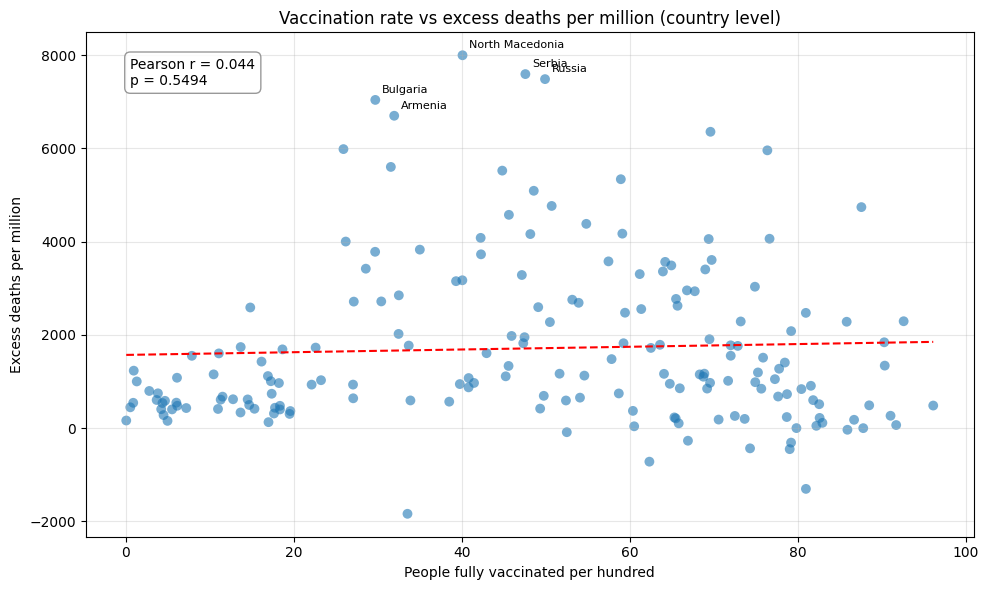

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot8_vax_vs_excess.png]


In [60]:
sep("8. VACCINATION RATE VS EXCESS DEATHS (PEARSON R)")

#normalizing names
NAME_MAP = {
    "Russian Federation":                    "Russia",
    "United States of America":              "United States",
    "Iran (Islamic Republic of)":            "Iran",
    "Republic of Korea":                     "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Bolivia (Plurinational State of)":      "Bolivia",
    "Venezuela (Bolivarian Republic of)":    "Venezuela",
    "Syrian Arab Republic":                  "Syria",
    "Viet Nam":                              "Vietnam",
    "Brunei Darussalam":                     "Brunei",
    "Cabo Verde":                            "Cape Verde",
    "Republic of Moldova":                   "Moldova",
    "Democratic Republic of the Congo":      "Democratic Republic of Congo",
    "Lao People's Democratic Republic":      "Laos",
    "United Republic of Tanzania":           "Tanzania",
}

excess_total = ( by_year[by_year["year"].astype(str).str.match(r"^\d{4}$")]
                .groupby("Country")[EXCESS]
                .sum()
                .reset_index()
                .rename(columns={EXCESS: "excess_total"})

)

excess_total["Country"] = excess_total["Country"].replace(NAME_MAP)

#vaccination peaked:
vax_peak = (
    vaccinations
    .groupby("country")["people_fully_vaccinated_per_hundred"]
    .max()
    .reset_index()
    .rename(columns={"country" : "Country",
                     "people_fully_vaccinated_per_hundred" : "vax_rate"})
)

#complete population dataset
pop = (
    complete
    .groupby("Country/Region")["Confirmed"]
    .max()
    .reset_index()
    .rename(columns={"Country/Region" : "Country"})

)

vax_pop = vaccinations.copy()
vax_pop = vax_pop.dropna(subset=["total_vaccinations", "total_vaccinations_per_hundred"])
vax_pop = vax_pop[vax_pop["total_vaccinations_per_hundred"] > 0]
vax_pop["pop_est"] = (
    vax_pop["total_vaccinations"] / vax_pop["total_vaccinations_per_hundred"] * 100
)

population = (
    vax_pop.groupby("country")["pop_est"]
    .max()
    .reset_index()
    .rename(columns={"country": "Country", "pop_est": "population"})
)

merged = (
    excess_total
    .merge(vax_peak,   on="Country", how="inner")
    .merge(population, on="Country", how="inner")
    .dropna(subset=["vax_rate", "excess_total", "population"])
)

merged["excess_per_million"] = merged["excess_total"] / merged["population"] * 1_000_000

print(f"Countries in analysis: {len(merged)}")

# pearson r
r, p = stats.pearsonr(merged["vax_rate"], merged["excess_per_million"])
print(f"\nPearson r  : {r:.4f}")
print(f"p-value    : {p:.4f}")
print(f"Significant: {'yes (p < 0.05)' if p < 0.05 else 'no'}")

# scatter and regression line
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    merged["vax_rate"],
    merged["excess_per_million"],
    alpha=0.6,
    edgecolors="none",
    s=50
)

m, b = np.polyfit(merged["vax_rate"], merged["excess_per_million"], 1)
x_line = np.linspace(merged["vax_rate"].min(), merged["vax_rate"].max(), 200)
ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--", label="Trend")

# Annotate r and p
ax.annotate(
    f"Pearson r = {r:.3f}\np = {p:.4f}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    fontsize=10, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Label top 5 outliers by excess per million
for _, row in merged.nlargest(5, "excess_per_million").iterrows():
    ax.annotate(
        row["Country"],
        xy=(row["vax_rate"], row["excess_per_million"]),
        xytext=(5, 5), textcoords="offset points", fontsize=8
    )

ax.set_xlabel("People fully vaccinated per hundred")
ax.set_ylabel("Excess deaths per million")
ax.set_title("Vaccination rate vs excess deaths per million (country level)")
ax.grid(alpha=0.3)
save_fig("plot8_vax_vs_excess")


  9. POLICY EFFECTIVENESS SCATTER


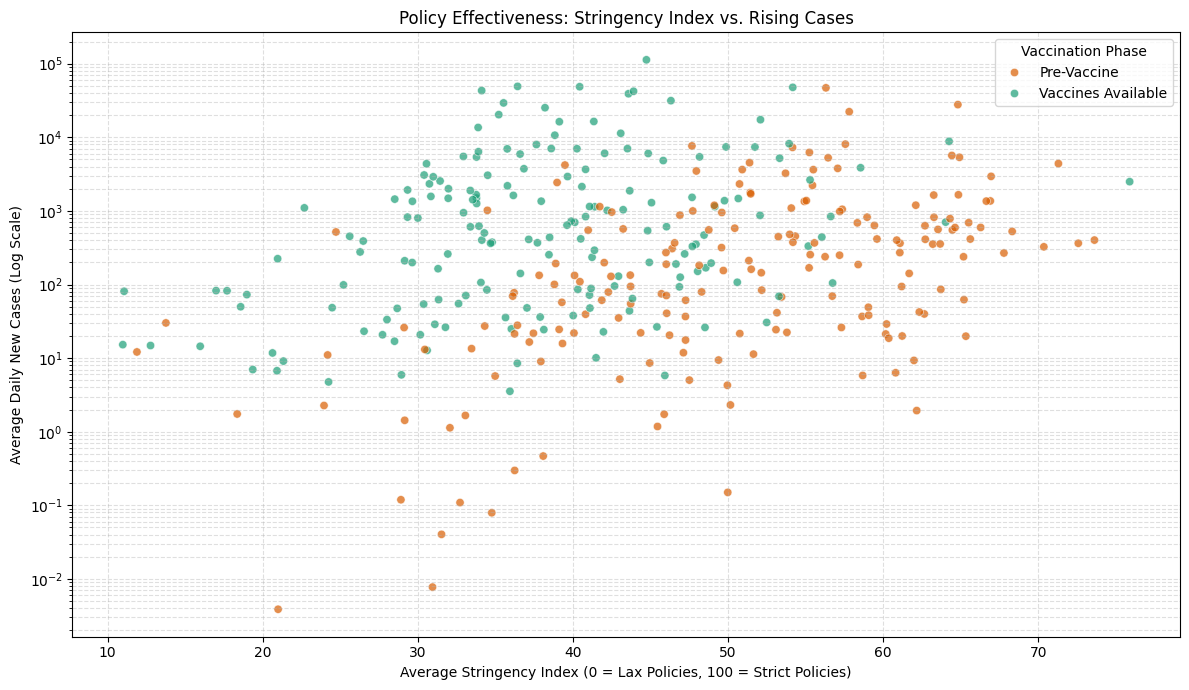

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot9_policy_effectiveness.png]


In [61]:
# policy effectiveness scatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sep("9. POLICY EFFECTIVENESS SCATTER")

oxcgrt = stringency
vax = vaccinations

oxcgrt['Date'] = pd.to_datetime(oxcgrt['Date'], format='%Y%m%d')
vax['date'] = pd.to_datetime(vax['date'])

#  Calculate Daily New Cases (rising cases) from the cumulative ConfirmedCases
oxcgrt = oxcgrt.sort_values(['CountryName', 'Date'])
oxcgrt['NewCases'] = oxcgrt.groupby('CountryName')['ConfirmedCases'].diff()
oxcgrt.loc[oxcgrt['NewCases'] < 0, 'NewCases'] = 0  #Remove negative corrections from data reporting anomalies

#Find the exact date vaccines became available for each country
first_vax = vax.groupby('country')['date'].min().reset_index()
first_vax.columns = ['CountryName', 'FirstVaxDate']

# Merge the policy data with the vaccination availability dates
data = pd.merge(oxcgrt, first_vax, on='CountryName', how='left')

# Split into two categories:
data['VaccineStatus'] = np.where(
    (data['FirstVaxDate'].isna()) | (data['Date'] < data['FirstVaxDate']),
    'Pre-Vaccine',
    'Vaccines Available'
)

agg_data = data.groupby(['CountryName', 'VaccineStatus']).agg(
    Avg_Stringency=('StringencyIndex_Average', 'mean'),
    Avg_DailyNewCases=('NewCases', 'mean')
).reset_index()

# Drop any rows with NaN values in our plotting axes
agg_data = agg_data.dropna(subset=['Avg_Stringency', 'Avg_DailyNewCases'])

# Plot the Policy Effectiveness Scatter
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=agg_data,
    x='Avg_Stringency',
    y='Avg_DailyNewCases',
    hue='VaccineStatus',
    alpha=0.7,
    palette={'Pre-Vaccine': '#d95f02', 'Vaccines Available': '#1b9e77'}
)

plt.yscale('log')

# Formatting the plot
plt.title('Policy Effectiveness: Stringency Index vs. Rising Cases')
plt.xlabel('Average Stringency Index (0 = Lax Policies, 100 = Strict Policies)')
plt.ylabel('Average Daily New Cases (Log Scale)')
plt.legend(title='Vaccination Phase')
plt.grid(True, which="both", ls="--", alpha=0.4)

save_fig("plot9_policy_effectiveness")




  10. CONFOUNDING VARIABLE CONTROL (OLS REGRESSION)
Countries used in regression : 154
R-squared                    : 0.075
Adjusted R-squared           : 0.044

Coefficients and p-values:
  vax_rate               coef=     45.13  p=0.022  *
  stringency_index       coef=    -12.15  p=0.419  
  peak_confirmed         coef=      0.00  p=0.008  **
  undercount_ratio       coef=      0.02  p=0.894  
  income_proxy           coef=  -1039.99  p=0.024  *


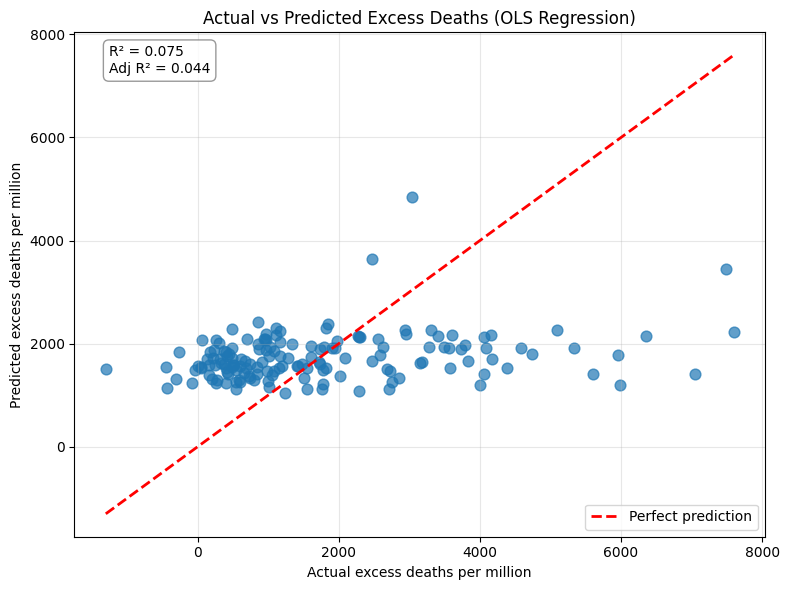

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot10_actual_vs_predicted_ols.png]


In [62]:
sep("10. CONFOUNDING VARIABLE CONTROL (OLS REGRESSION)")

import statsmodels.api as sm

# ── Load OxCGRT ───────────────────────────────────────────────────────────────
oxcgrt = stringency
stringency_country = (
    oxcgrt
    .groupby("CountryName")["StringencyIndex_Average"]
    .mean()
    .reset_index()
    .rename(columns={"CountryName": "Country",
                     "StringencyIndex_Average": "stringency_index"})
)

# ── Build structural predictors from existing datasets ────────────────────────
# 1. Undercount ratio: excess / confirmed deaths (proxy for health system quality)
confirmed_deaths = (
    complete
    .groupby("Country/Region")["Deaths"]
    .max()
    .reset_index()
    .rename(columns={"Country/Region": "Country", "Deaths": "confirmed_deaths"})
)
confirmed_deaths["Country"] = confirmed_deaths["Country"].astype(str).str.strip()

# 2. Peak case burden per country (proxy for outbreak severity)
peak_cases = (
    complete
    .groupby("Country/Region")["Confirmed"]
    .max()
    .reset_index()
    .rename(columns={"Country/Region": "Country", "Confirmed": "peak_confirmed"})
)
peak_cases["Country"] = peak_cases["Country"].astype(str).str.strip()

# 3. Income group (ordinal encoding from vaccinations equity data)
income_map = {"Low income": 1, "Lower middle income": 2,
              "Upper middle income": 3, "High income": 4}

# Derive income group from vax coverage quartiles as proxy
merged["income_proxy"] = pd.qcut(
    merged["vax_rate"],
    q=4,
    labels=[1, 2, 3, 4]
).astype(float)

# ── Assemble regression dataframe ─────────────────────────────────────────────
regression_df = (
    merged
    .merge(stringency_country,  on="Country", how="left")
    .merge(confirmed_deaths,    on="Country", how="left")
    .merge(peak_cases,          on="Country", how="left")
    .dropna(subset=["vax_rate", "stringency_index",
                    "excess_per_million", "confirmed_deaths",
                    "peak_confirmed", "income_proxy"])
    .copy()
)

# Undercount ratio
regression_df["undercount_ratio"] = (
    regression_df["excess_total"] / regression_df["confirmed_deaths"].replace(0, np.nan)
).fillna(1)

# ── Fit OLS ───────────────────────────────────────────────────────────────────
predictors = ["vax_rate", "stringency_index",
              "peak_confirmed", "undercount_ratio", "income_proxy"]

X = sm.add_constant(regression_df[predictors])
y = regression_df["excess_per_million"]

model = sm.OLS(y, X).fit()
regression_df["predicted_excess"] = model.predict(X)

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"Countries used in regression : {len(regression_df)}")
print(f"R-squared                    : {model.rsquared:.3f}")
print(f"Adjusted R-squared           : {model.rsquared_adj:.3f}")
print()
print("Coefficients and p-values:")
for var in predictors:
    coef = model.params[var]
    pval = model.pvalues[var]
    sig  = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"  {var:<22} coef={coef:>10.2f}  p={pval:.3f}  {sig}")

# ── Actual vs predicted plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(regression_df["excess_per_million"],
           regression_df["predicted_excess"],
           alpha=0.7, s=60)

min_val = min(regression_df["excess_per_million"].min(),
              regression_df["predicted_excess"].min())
max_val = max(regression_df["excess_per_million"].max(),
              regression_df["predicted_excess"].max())

ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", linewidth=2, color="red", label="Perfect prediction")

# Annotate R-squared on chart
ax.annotate(f"R² = {model.rsquared:.3f}\nAdj R² = {model.rsquared_adj:.3f}",
            xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="gray", alpha=0.8))

ax.set_xlabel("Actual excess deaths per million")
ax.set_ylabel("Predicted excess deaths per million")
ax.set_title("Actual vs Predicted Excess Deaths (OLS Regression)")
ax.legend()
ax.grid(alpha=0.3)
save_fig("plot10_actual_vs_predicted_ols")

In [63]:
import warnings
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

INCOME_ORDER  = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
INCOME_COLORS = {
    'High income':          '#2196F3',
    'Upper middle income':  '#4CAF50',
    'Lower middle income':  '#FF9800',
    'Low income':           '#F44336',
}

sep('11. VACCINATION EQUITY GAP — COUNTRY & INCOME GROUP LEVELS')

vax_country = (
    vaccinations
    .groupby('country')['people_fully_vaccinated_per_hundred']
    .max()
    .reset_index()
    .rename(columns={'country': 'Country',
                     'people_fully_vaccinated_per_hundred': 'vax_rate'})
    .dropna(subset=['vax_rate'])
)

# World Bank income group classification
INCOME_MAP = {
    # --- High income ---
    'United States': 'High income', 'United Kingdom': 'High income',
    'Germany': 'High income', 'France': 'High income', 'Japan': 'High income',
    'Canada': 'High income', 'Australia': 'High income', 'Italy': 'High income',
    'Spain': 'High income', 'South Korea': 'High income', 'Netherlands': 'High income',
    'Sweden': 'High income', 'Switzerland': 'High income', 'Belgium': 'High income',
    'Austria': 'High income', 'Norway': 'High income', 'Denmark': 'High income',
    'Finland': 'High income', 'New Zealand': 'High income', 'Israel': 'High income',
    'Singapore': 'High income', 'Portugal': 'High income', 'Greece': 'High income',
    'Czech Republic': 'High income', 'Chile': 'High income', 'Hungary': 'High income',
    'Poland': 'High income', 'Romania': 'High income', 'Slovakia': 'High income',
    'Croatia': 'High income', 'Lithuania': 'High income', 'Latvia': 'High income',
    'Estonia': 'High income', 'Slovenia': 'High income', 'Cyprus': 'High income',
    'Malta': 'High income', 'Luxembourg': 'High income', 'Iceland': 'High income',
    'Ireland': 'High income', 'United Arab Emirates': 'High income',
    'Qatar': 'High income', 'Kuwait': 'High income', 'Bahrain': 'High income',
    'Saudi Arabia': 'High income', 'Oman': 'High income', 'Brunei': 'High income',
    # --- Upper middle income ---
    'Russia': 'Upper middle income', 'China': 'Upper middle income',
    'Brazil': 'Upper middle income', 'Mexico': 'Upper middle income',
    'Turkey': 'Upper middle income', 'South Africa': 'Upper middle income',
    'Thailand': 'Upper middle income', 'Malaysia': 'Upper middle income',
    'Colombia': 'Upper middle income', 'Peru': 'Upper middle income',
    'Argentina': 'Upper middle income', 'Ecuador': 'Upper middle income',
    'Dominican Republic': 'Upper middle income', 'Venezuela': 'Upper middle income',
    'Cuba': 'Upper middle income', 'Paraguay': 'Upper middle income',
    'Albania': 'Upper middle income', 'Serbia': 'Upper middle income',
    'Bosnia and Herzegovina': 'Upper middle income', 'North Macedonia': 'Upper middle income',
    'Montenegro': 'Upper middle income', 'Belarus': 'Upper middle income',
    'Kazakhstan': 'Upper middle income', 'Azerbaijan': 'Upper middle income',
    'Armenia': 'Upper middle income', 'Georgia': 'Upper middle income',
    'Jordan': 'Upper middle income', 'Lebanon': 'Upper middle income',
    'Iran': 'Upper middle income', 'Iraq': 'Upper middle income',
    'Libya': 'Upper middle income', 'Algeria': 'Upper middle income',
    'Tunisia': 'Upper middle income', 'Namibia': 'Upper middle income',
    'Botswana': 'Upper middle income', 'Fiji': 'Upper middle income',
    'Maldives': 'Upper middle income', 'Jamaica': 'Upper middle income',
    'Suriname': 'Upper middle income', 'Mongolia': 'Upper middle income',
    # --- Lower middle income ---
    'India': 'Lower middle income', 'Indonesia': 'Lower middle income',
    'Pakistan': 'Lower middle income', 'Bangladesh': 'Lower middle income',
    'Philippines': 'Lower middle income', 'Vietnam': 'Lower middle income',
    'Nigeria': 'Lower middle income', 'Egypt': 'Lower middle income',
    'Kenya': 'Lower middle income', 'Ghana': 'Lower middle income',
    'Senegal': 'Lower middle income', 'Morocco': 'Lower middle income',
    'Zimbabwe': 'Lower middle income', 'Ukraine': 'Lower middle income',
    'Moldova': 'Lower middle income', 'Bolivia': 'Lower middle income',
    'El Salvador': 'Lower middle income', 'Honduras': 'Lower middle income',
    'Nicaragua': 'Lower middle income', 'Cambodia': 'Lower middle income',
    'Myanmar': 'Lower middle income', 'Laos': 'Lower middle income',
    'Nepal': 'Lower middle income', 'Sri Lanka': 'Lower middle income',
    'Papua New Guinea': 'Lower middle income', 'Ivory Coast': 'Lower middle income',
    'Cameroon': 'Lower middle income', 'Angola': 'Lower middle income',
    'Sudan': 'Lower middle income', 'Uganda': 'Lower middle income',
    'Tanzania': 'Lower middle income', 'Ethiopia': 'Lower middle income',
    'Zambia': 'Lower middle income', 'Mauritania': 'Lower middle income',
    'Djibouti': 'Lower middle income', 'Congo': 'Lower middle income',
    'Eswatini': 'Lower middle income', 'Lesotho': 'Lower middle income',
    'Kyrgyzstan': 'Lower middle income', 'Tajikistan': 'Lower middle income',
    'Uzbekistan': 'Lower middle income', 'Tonga': 'Lower middle income',
    # --- Low income ---
    'Afghanistan': 'Low income', 'Somalia': 'Low income',
    'Niger': 'Low income', 'Mali': 'Low income',
    'Burkina Faso': 'Low income', 'Guinea': 'Low income',
    'Sierra Leone': 'Low income', 'Liberia': 'Low income',
    'Togo': 'Low income', 'Benin': 'Low income',
    'Malawi': 'Low income', 'Mozambique': 'Low income',
    'Rwanda': 'Low income', 'Burundi': 'Low income',
    'Chad': 'Low income', 'Central African Republic': 'Low income',
    'South Sudan': 'Low income', 'Democratic Republic of Congo': 'Low income',
    'Haiti': 'Low income', 'North Korea': 'Low income',
    'Gambia': 'Low income', 'Guinea-Bissau': 'Low income',
    'Eritrea': 'Low income', 'Madagascar': 'Low income',
    'Yemen': 'Low income', 'Syria': 'Low income',
}

vax_country['income_group'] = vax_country['Country'].map(INCOME_MAP)
vax_cc = vax_country.dropna(subset=['income_group']).copy()

income_summary = (
    vax_cc.groupby('income_group')['vax_rate']
    .agg(['count','median','mean','std'])
    .round(2)
    .rename(columns={'count':'n','median':'Median %','mean':'Mean %','std':'Std Dev'})
)
print('\nVaccination Rate Summary by Income Group:')
print(income_summary.to_string())


  11. VACCINATION EQUITY GAP — COUNTRY & INCOME GROUP LEVELS

Vaccination Rate Summary by Income Group:
                      n  Median %  Mean %  Std Dev
income_group                                      
High income          45     74.94   74.56    11.65
Low income           24      7.56   12.40    13.88
Lower middle income  41     33.70   36.08    23.94
Upper middle income  40     49.84   51.23    20.70


## Mortality Impact Classification

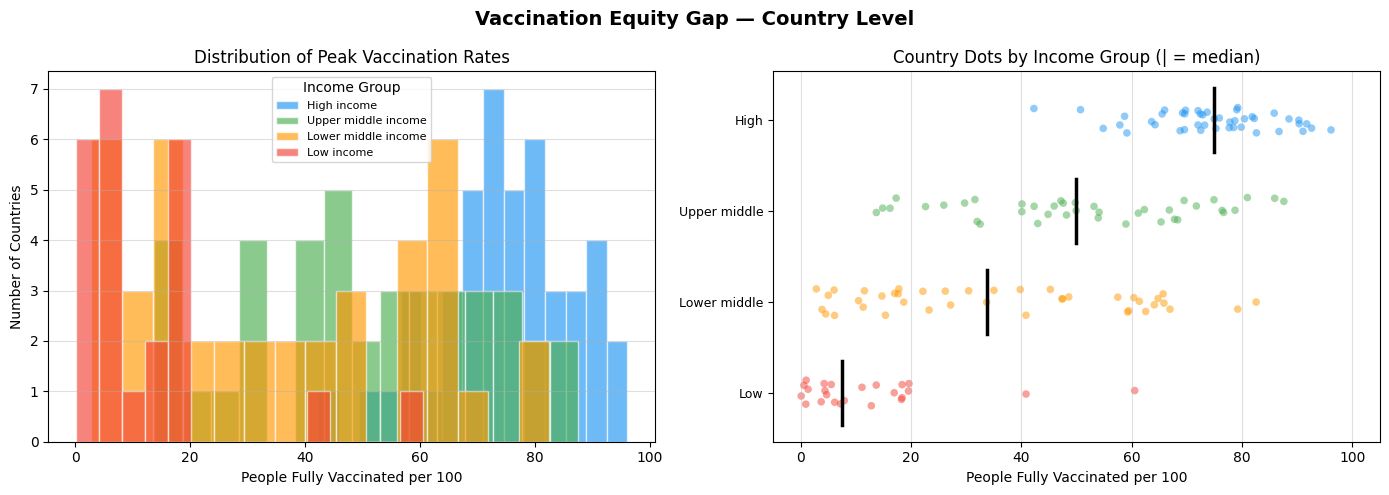

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot_vax_equity_country_level.png]


In [64]:
# ## Figure A — Country-Level Distribution
#
# Histogram and strip plot showing how vaccination rates are distributed across countries, grouped by income tier.

# ── FIGURE A: Country-level distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vaccination Equity Gap — Country Level', fontsize=14, fontweight='bold')

ax = axes[0]
for grp in INCOME_ORDER:
    subset = vax_cc[vax_cc['income_group'] == grp]['vax_rate']
    ax.hist(subset, bins=15, alpha=0.65, label=grp,
            color=INCOME_COLORS[grp], edgecolor='white')
ax.set_title('Distribution of Peak Vaccination Rates')
ax.set_xlabel('People Fully Vaccinated per 100')
ax.set_ylabel('Number of Countries')
ax.legend(title='Income Group', fontsize=8)
ax.grid(axis='y', alpha=0.4)

ax2 = axes[1]
for i, grp in enumerate(INCOME_ORDER):
    subset = vax_cc[vax_cc['income_group'] == grp]['vax_rate'].sort_values()
    jitter = np.random.uniform(-0.15, 0.15, len(subset))
    ax2.scatter(subset, i + jitter, alpha=0.5, s=30,
               color=INCOME_COLORS[grp], edgecolors='none')
    med = subset.median()
    ax2.plot([med, med], [i - 0.35, i + 0.35],
             color='black', linewidth=2.5, zorder=5)

ax2.set_yticks(range(len(INCOME_ORDER)))
ax2.set_yticklabels([g.replace(' income','') for g in INCOME_ORDER], fontsize=9)
ax2.set_xlabel('People Fully Vaccinated per 100')
ax2.set_title('Country Dots by Income Group (| = median)')
ax2.set_xlim(-5, 105)
ax2.grid(axis='x', alpha=0.4)
ax2.invert_yaxis()
save_fig('plot_vax_equity_country_level')

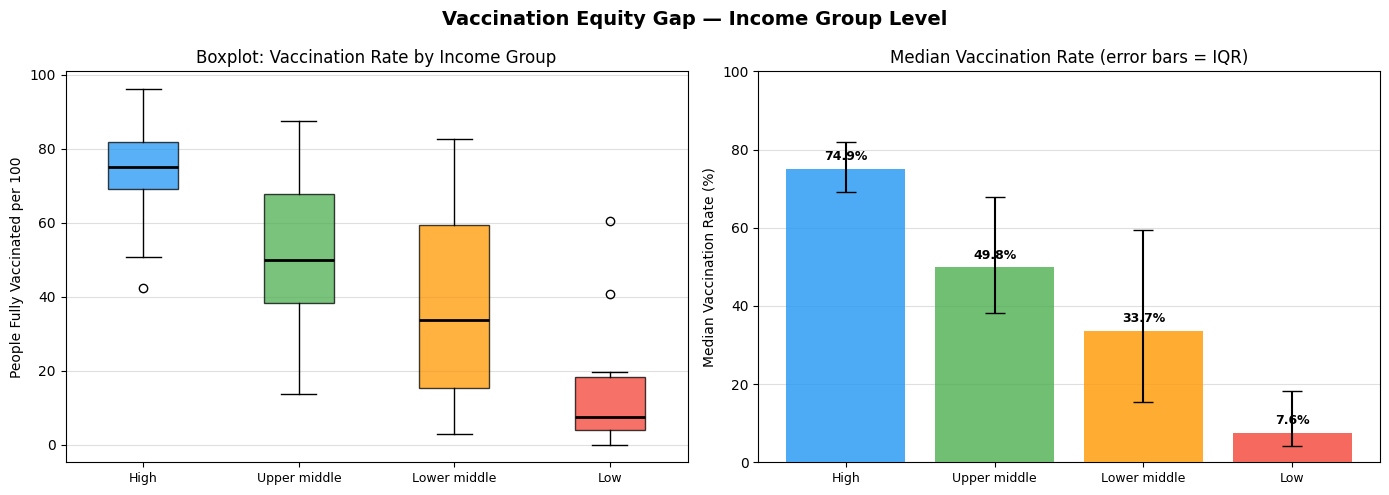

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot11_vax_equity_income_group.png]


In [65]:
# ## Figure B — Income Group Level
#
# Boxplots and median bar chart comparing vaccination rates across the four World Bank income groups.

# ── FIGURE B: Income group boxplot + median bars ──────────────────────────
data_by_group = [
    vax_cc[vax_cc['income_group'] == grp]['vax_rate'].dropna().values
    for grp in INCOME_ORDER
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vaccination Equity Gap — Income Group Level', fontsize=14, fontweight='bold')

ax = axes[0]
bp = ax.boxplot(data_by_group, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, grp in zip(bp['boxes'], INCOME_ORDER):
    patch.set_facecolor(INCOME_COLORS[grp])
    patch.set_alpha(0.75)
ax.set_xticklabels([g.replace(' income','') for g in INCOME_ORDER], fontsize=9)
ax.set_ylabel('People Fully Vaccinated per 100')
ax.set_title('Boxplot: Vaccination Rate by Income Group')
ax.grid(axis='y', alpha=0.4)

ax2 = axes[1]
medians = [np.median(d) for d in data_by_group]
q1s     = [np.percentile(d, 25) for d in data_by_group]
q3s     = [np.percentile(d, 75) for d in data_by_group]
errs_lo = [m - q1 for m, q1 in zip(medians, q1s)]
errs_hi = [q3 - m  for m, q3 in zip(medians, q3s)]
bars = ax2.bar(range(4), medians,
               color=[INCOME_COLORS[g] for g in INCOME_ORDER],
               alpha=0.8, zorder=3)
ax2.errorbar(range(4), medians, yerr=[errs_lo, errs_hi],
             fmt='none', color='black', capsize=7, linewidth=1.5, zorder=5)
for bar, med in zip(bars, medians):
    ax2.text(bar.get_x() + bar.get_width()/2, med + 1.5,
             f'{med:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(4))
ax2.set_xticklabels([g.replace(' income','') for g in INCOME_ORDER], fontsize=9)
ax2.set_ylabel('Median Vaccination Rate (%)')
ax2.set_title('Median Vaccination Rate (error bars = IQR)')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.4, zorder=0)
save_fig('plot11_vax_equity_income_group')



  11b. STATISTICAL CORRELATION: INCOME GROUP vs VACCINATION RATE
Spearman ρ  : 0.7519  p = 1.46e-28  ✓ significant
Pearson  r  : 0.7569  p = 3.95e-29  ✓ significant
Kruskal-Wallis H: 85.37  p = 2.17e-18  ✓ groups differ

Vaccination Equity Gap (High − Low income median): 67.4 percentage points


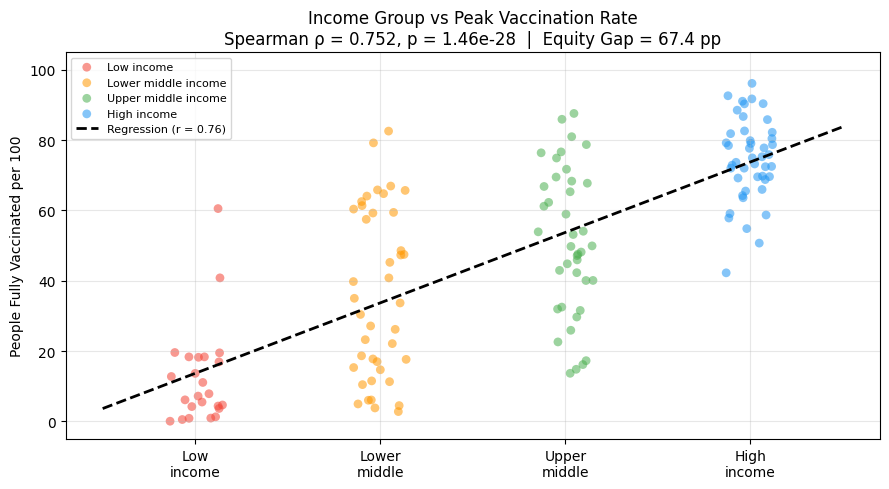

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot12_vax_equity_correlation.png]

[Vaccination Equity Gap analysis complete]


In [66]:

# ## Figure C — Statistical Correlation
#
# Spearman ρ, Pearson r, and Kruskal-Wallis test to quantify the income–vaccination relationship. Scatter with regression line shows directionality.

# ── FIGURE C: Statistical Correlation ────────────────────────────────────
sep('11b. STATISTICAL CORRELATION: INCOME GROUP vs VACCINATION RATE')

INCOME_RANK = {'Low income':1, 'Lower middle income':2,
               'Upper middle income':3, 'High income':4}
vax_cc['income_rank'] = vax_cc['income_group'].map(INCOME_RANK)

r_sp, p_sp = stats.spearmanr(vax_cc['income_rank'], vax_cc['vax_rate'])
r_pe, p_pe = stats.pearsonr(vax_cc['income_rank'],  vax_cc['vax_rate'])
kw_stat, kw_p = stats.kruskal(*data_by_group)

print(f'Spearman ρ  : {r_sp:.4f}  p = {p_sp:.2e}  {"✓ significant" if p_sp<0.05 else "✗ not significant"}')
print(f'Pearson  r  : {r_pe:.4f}  p = {p_pe:.2e}  {"✓ significant" if p_pe<0.05 else "✗ not significant"}')
print(f'Kruskal-Wallis H: {kw_stat:.2f}  p = {kw_p:.2e}  {"✓ groups differ" if kw_p<0.05 else "✗ no difference"}')

high_med = np.median(data_by_group[0])
low_med  = np.median(data_by_group[3])
gap      = high_med - low_med
print(f'\nVaccination Equity Gap (High − Low income median): {gap:.1f} percentage points')

fig, ax = plt.subplots(figsize=(9, 5))
for grp, rank in INCOME_RANK.items():
    subset = vax_cc[vax_cc['income_group'] == grp]
    jitter = np.random.uniform(-0.15, 0.15, len(subset))
    ax.scatter(rank + jitter, subset['vax_rate'],
               color=INCOME_COLORS[grp], alpha=0.55, s=40, label=grp, edgecolors='none')

slope, intercept, *_ = stats.linregress(vax_cc['income_rank'], vax_cc['vax_rate'])
x_line = np.linspace(0.5, 4.5, 100)
ax.plot(x_line, slope*x_line + intercept, color='black', linewidth=2,
        linestyle='--', label=f'Regression (r = {r_pe:.2f})')

ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['Low\nincome','Lower\nmiddle','Upper\nmiddle','High\nincome'])
ax.set_ylabel('People Fully Vaccinated per 100')
ax.set_title(f'Income Group vs Peak Vaccination Rate\n'
             f'Spearman ρ = {r_sp:.3f}, p = {p_sp:.2e}  |  Equity Gap = {gap:.1f} pp')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(-5, 105)
save_fig('plot12_vax_equity_correlation')

print('\n[Vaccination Equity Gap analysis complete]')



  12. MORTALITY IMPACT CLASSIFICATION

Countries classified by Mortality Impact (sample):
High Mortality Impact:


,Country,excess_per_million,mortality_impact
147,Serbia,7595.142857,High
137,Russia,7487.318276,High
25,Bulgaria,7041.186736,High
96,Lithuania,6357.748370,High
21,Bosnia and Herzegovina,5985.940133,High
129,Peru,5959.356725,High
62,Georgia,5603.736799,High
15,Belarus,5340.021008,High
20,Bolivia,5091.881687,High
42,Cuba,4741.531650,High


Low Mortality Impact:


,Country,excess_per_million,mortality_impact
148,Seychelles,-1302.900000,Low
117,New Zealand,-450.569106,Low
19,Bhutan,-433.353840,Low
181,Vietnam,-309.919348,Low
158,Sri Lanka,-269.844873,Low
14,Barbados,-86.787371,Low
35,China,-34.736667,Low
83,Japan,1.095707,Low
138,Rwanda,39.642636,Low
8,Australia,50.340624,Low



Mortality Impact Distribution by Income Group:


mortality_impact,Low,Moderate,High
income_group,,,
High income,0.333333,0.404762,0.261905
Upper middle income,0.114286,0.200000,0.685714
Lower middle income,0.351351,0.378378,0.270270
Low income,0.727273,0.272727,0.000000


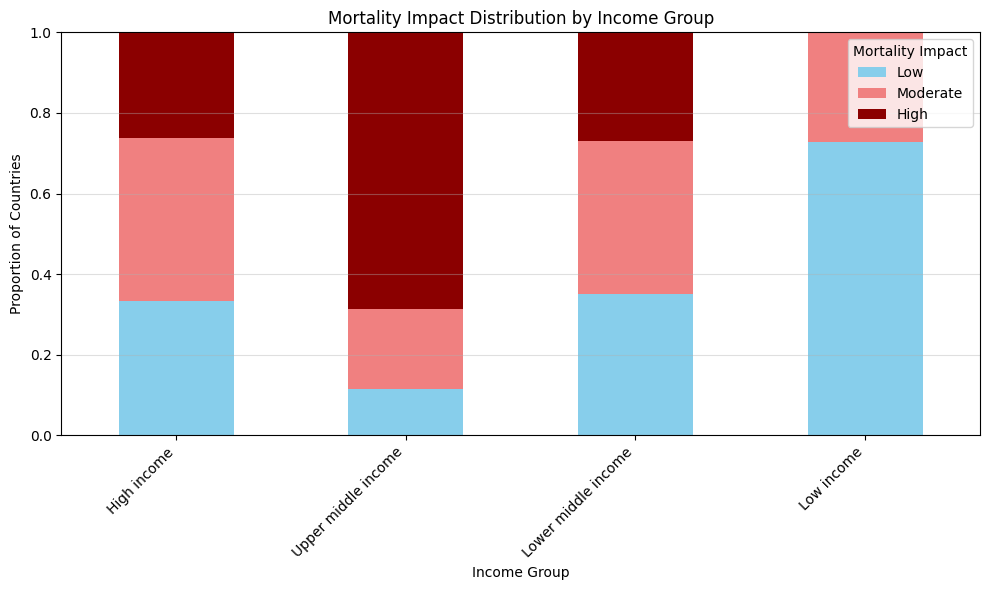

  [saved /Users/urielle.zach/COVID-19 Analysis/plots/plot13_mortality_impact_by_income_group.png]


In [67]:
sep('12. MORTALITY IMPACT CLASSIFICATION')

# Calculate quantiles for excess_per_million
low_threshold = regression_df['excess_per_million'].quantile(0.33)
medium_threshold = regression_df['excess_per_million'].quantile(0.66)

# Define a function to classify mortality impact
def classify_mortality_impact(excess_deaths):
    if excess_deaths <= low_threshold:
        return 'Low'
    elif excess_deaths <= medium_threshold:
        return 'Moderate'
    else:
        return 'High'

# Apply the classification to the DataFrame
regression_df['mortality_impact'] = regression_df['excess_per_million'].apply(classify_mortality_impact)

# Display the classification for a sample of countries
print("\nCountries classified by Mortality Impact (sample):")
print("High Mortality Impact:")
display(regression_df[['Country', 'excess_per_million', 'mortality_impact']].sort_values('excess_per_million', ascending=False).head(10))
print("Low Mortality Impact:")
display(regression_df[['Country', 'excess_per_million', 'mortality_impact']].sort_values('excess_per_million', ascending=True).head(10))

# Summarize mortality impact by income group
# Merge income_group from vax_cc to regression_df
regression_df = regression_df.merge(vax_cc[['Country', 'income_group']], on='Country', how='left')

# Drop countries that do not have an assigned income group after merge
regression_df.dropna(subset=['income_group'], inplace=True)

impact_by_income = regression_df.groupby('income_group')['mortality_impact'].value_counts(normalize=True).unstack(fill_value=0)
impact_by_income = impact_by_income[['Low', 'Moderate', 'High']]

# Ensure the order of income groups for plotting
impact_by_income = impact_by_income.reindex(INCOME_ORDER)

print("\nMortality Impact Distribution by Income Group:")
display(impact_by_income)

# Plotting the distribution of mortality impact by income group
impact_by_income.plot(kind='bar', stacked=True, figsize=(10, 6), color={'Low': 'skyblue', 'Moderate': 'lightcoral', 'High': 'darkred'})
plt.title('Mortality Impact Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Proportion of Countries')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mortality Impact')
plt.grid(axis='y', alpha=0.4)
save_fig('plot13_mortality_impact_by_income_group')